In [1]:
from exam_load import ExamLoad
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# 1. 配置
# ============================================================
FILE_PATTERN = re.compile(r"^(?P<subject>\d+)_(?P<condition>|mid|low)\.kinarm$")

# 如果你想改读取目录，就改这里
DATA_DIR = Path(".")

# ============================================================
# 2. 基础工具函数
# ============================================================
def safe_scalarize(x):
    """
    把 parameter 里的各种 array / bytes / list 尽量转成适合 dataframe 的值
    """
    if x is None:
        return np.nan

    if isinstance(x, (bytes, bytearray)):
        return list(x)

    if hasattr(x, "__len__") and not isinstance(x, (str, bytes, bytearray, dict)):
        try:
            n = len(x)
        except Exception:
            return x

        if n == 0:
            return np.nan
        elif n == 1:
            try:
                return x[0]
            except Exception:
                return str(x)
        else:
            try:
                return list(x)
            except Exception:
                return str(x)

    return x


def to_col_vector(values, dtype=float):
    """
    转成列向量形状: (n, 1)
    """
    arr = np.asarray(values, dtype=dtype)
    if arr.ndim == 0:
        arr = arr.reshape(1, 1)
    elif arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return arr


def split_xy_to_col_vectors(values):
    """
    values: [(x1,y1), (x2,y2), ...]
    返回 x, y 两个列向量，shape = (n,1)
    """
    if values is None or len(values) == 0:
        empty = np.empty((0, 1), dtype=float)
        return empty, empty

    arr = np.asarray(values, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        empty = np.empty((0, 1), dtype=float)
        return empty, empty

    return arr[:, 0].reshape(-1, 1), arr[:, 1].reshape(-1, 1)


def get_max_frame_len(trial):
    """
    尽量稳健地确定这个 trial 的帧数。
    优先用 header 里的 frame_count；
    如果缺失，则从 kinematics / positions / ack_times 实际长度里取最大值。
    """
    lengths = []

    fc = getattr(trial, "frame_count", None)
    if fc not in [None, 0]:
        lengths.append(int(fc))

    for obj in trial.kinematics.values():
        lengths.append(len(obj.values))

    for obj in trial.positions.values():
        lengths.append(len(obj.values))

    if getattr(trial, "ack_times", None):
        lengths.append(len(trial.ack_times))

    return max(lengths) if lengths else 0


def trial_sort_key(trial_name):
    """
    排序依据主要看中间那段数字，例如 05_211_01 里的 211。
    这里优先按“第二段数字”排序，再按第一段、第三段。
    """
    nums = [int(x) for x in re.findall(r"\d+", str(trial_name))]

    if len(nums) >= 3:
        return (nums[1], nums[0], nums[2], str(trial_name))
    elif len(nums) == 2:
        return (nums[1], nums[0], 0, str(trial_name))
    elif len(nums) == 1:
        return (nums[0], 0, 0, str(trial_name))
    else:
        return (10**12, 10**12, 10**12, str(trial_name))


def file_sort_key(path_obj):
    m = FILE_PATTERN.match(path_obj.name)
    if m is None:
        return (10**12, "zzz", path_obj.name)
    return (int(m.group("subject")), m.group("condition"), path_obj.name)


def make_preview_cell(x):
    """
    仅用于 display 的预览表，不改原始 df_trials。
    """
    if isinstance(x, np.ndarray):
        if x.ndim == 2 and x.shape[1] == 1:
            return f"{x.shape[0]}x1 double"
        return f"{'x'.join(map(str, x.shape))} double"

    if isinstance(x, list):
        if len(x) == 0:
            return "0x0 list"
        if isinstance(x[0], dict):
            return f"{len(x)} events"
        return f"{len(x)} items"

    return x


def build_event_rows(subject_id, condition, source_file, trial_name, trial):
    """
    事件表：一行一个 event

    frame 的定义采用：
        event_time_s 落到“第一个时间 >= event_time_s 的帧”
    也就是 np.searchsorted(frame_times, event_time_s, side='left')
    """
    rows = []
    frame_rate = float(getattr(trial, "frame_rate", np.nan))
    n_frames = get_max_frame_len(trial)

    if np.isfinite(frame_rate) and frame_rate > 0 and n_frames > 0:
        frame_times = np.arange(n_frames, dtype=float) / frame_rate
    else:
        frame_times = None

    ack_times = getattr(trial, "ack_times", []) or []
    ack_send = np.array([x[0] for x in ack_times], dtype=float) if len(ack_times) > 0 else np.array([])
    ack_recv = np.array([x[1] for x in ack_times], dtype=float) if len(ack_times) > 0 else np.array([])

    for event_idx, e in enumerate(getattr(trial, "events", []), start=1):
        event_time = getattr(e, "time", np.nan)

        frame_idx0 = np.nan
        frame_idx1 = np.nan
        frame_time_s = np.nan

        if frame_times is not None and np.isfinite(event_time):
            idx = int(np.searchsorted(frame_times, event_time, side="left"))
            idx = min(max(idx, 0), n_frames - 1)
            frame_idx0 = idx
            frame_idx1 = idx + 1
            frame_time_s = frame_times[idx]

        ack_idx0 = np.nan
        ack_idx1 = np.nan
        ack_send_s = np.nan
        ack_time_s = np.nan

        if ack_send.size > 0 and np.isfinite(event_time):
            idx_ack = int(np.searchsorted(ack_send, event_time, side="left"))
            if idx_ack >= ack_send.size:
                idx_ack = ack_send.size - 1
            ack_idx0 = idx_ack
            ack_idx1 = idx_ack + 1
            ack_send_s = ack_send[idx_ack]
            ack_time_s = ack_recv[idx_ack]

        rows.append({
            "subject_id": subject_id,
            "condition": condition,
            "source_file": source_file,
            "trial_name": trial_name,
            "event_index_in_trial": event_idx,
            "event_label": getattr(e, "label", ""),
            "event_description": getattr(e, "description", ""),
            "event_time_s": event_time,
            "event_frame_idx_0based": frame_idx0,
            "event_frame_idx_1based": frame_idx1,
            "event_frame_time_s": frame_time_s,
            "event_ack_idx_0based": ack_idx0,
            "event_ack_idx_1based": ack_idx1,
            "event_ack_send_time_s": ack_send_s,
            "event_ack_time_s": ack_time_s,
        })

    return rows


def build_trial_row(subject_id, condition, source_file, trial_name, trial):
    """
    trial 级宽表：一行一个 trial
    每个通道直接塞进这一行里，保持接近 MATLAB 读出来的样子
    """
    row = {
        "subject_id": subject_id,
        "condition": condition,
        "source_file": source_file,
        "trial_name": trial_name,
        "save_name": getattr(trial, "save_name", ""),
        "frame_count_header": getattr(trial, "frame_count", np.nan),
        "frame_rate": getattr(trial, "frame_rate", np.nan),
        "n_kinematics_channels": len(getattr(trial, "kinematics", {})),
        "n_position_channels": len(getattr(trial, "positions", {})),
        "n_events": len(getattr(trial, "events", [])),
        "n_ack_times": len(getattr(trial, "ack_times", [])),
        "kinematic_channels": list(getattr(trial, "kinematics", {}).keys()),
        "position_channels": list(getattr(trial, "positions", {}).keys()),
        "parameter_keys": list(getattr(trial, "parameters", {}).keys()),
        "ack_times_raw": list(getattr(trial, "ack_times", [])),
    }

    # 事件也集中到 trial 这一行里
    event_rows = build_event_rows(subject_id, condition, source_file, trial_name, trial)
    row["events_raw"] = event_rows
    row["event_labels"] = [x["event_label"] for x in event_rows]
    row["event_descriptions"] = [x["event_description"] for x in event_rows]
    row["event_times_s"] = [x["event_time_s"] for x in event_rows]
    row["event_frame_idx_0based"] = [x["event_frame_idx_0based"] for x in event_rows]
    row["event_frame_idx_1based"] = [x["event_frame_idx_1based"] for x in event_rows]
    row["event_ack_idx_0based"] = [x["event_ack_idx_0based"] for x in event_rows]
    row["event_ack_idx_1based"] = [x["event_ack_idx_1based"] for x in event_rows]

    # kinematics: 保持原始通道名，单元格里是列向量
    for ch_name, obj in trial.kinematics.items():
        row[ch_name] = to_col_vector(obj.values, dtype=float)

    # positions: 拆成 X / Y 两列，尽量贴近 MATLAB 风格
    for pos_name, obj in trial.positions.items():
        x, y = split_xy_to_col_vectors(obj.values)
        row[f"{pos_name}X"] = x
        row[f"{pos_name}Y"] = y

    # parameters: 仍然展开到当前 trial 行里
    for k, v in trial.parameters.items():
        row[f"param__{k}"] = safe_scalarize(v)

    return row


# ============================================================
# 3. 读取 数据文件，全部放进一个 all_data
# ============================================================
kinarm_files = sorted(
    [
        f for f in DATA_DIR.iterdir()
        if f.is_file() and FILE_PATTERN.match(f.name)
    ],
    key=file_sort_key
)

if len(kinarm_files) == 0:
    raise FileNotFoundError("当前目录下没有匹配到 *.kinarm 文件。")

print("找到以下文件：")
for f in kinarm_files:
    print("  ", f.name)

# 结构: all_data[subject_id][condition] = {"file_name":..., "exam":..., "trial_names_sorted":[...]}
all_data = {}

trial_rows = []
event_rows_all = []

for f in kinarm_files:
    m = FILE_PATTERN.match(f.name)
    subject_id = m.group("subject")
    condition = m.group("condition")

    print(f"\n读取: {f.name}")
    exam = ExamLoad(str(f))

    raw_trial_names = list(exam.trials.keys())
    sorted_trial_names = sorted(raw_trial_names, key=trial_sort_key)

    print(f"  subject_id = {subject_id}")
    print(f"  condition  = {condition}")
    print(f"  trial数    = {len(sorted_trial_names)}")

    all_data.setdefault(subject_id, {})
    all_data[subject_id][condition] = {
        "file_name": f.name,
        "exam": exam,
        "trial_names_sorted": sorted_trial_names,
    }

    for trial_name in sorted_trial_names:
        trial = exam.trials[trial_name]

        # trial 
        row = build_trial_row(
            subject_id=subject_id,
            condition=condition,
            source_file=f.name,
            trial_name=trial_name,
            trial=trial
        )
        trial_rows.append(row)

        # event 
        event_rows_all.extend(
            build_event_rows(
                subject_id=subject_id,
                condition=condition,
                source_file=f.name,
                trial_name=trial_name,
                trial=trial
            )
        )

# ============================================================
# 4. 合成 DataFrame
# ============================================================
df_trials = pd.DataFrame(trial_rows)
df_events = pd.DataFrame(event_rows_all)

# 再统一排一次序，保证最终表顺序稳定
if len(df_trials) > 0:
    df_trials["__trial_sort_key__"] = df_trials["trial_name"].map(trial_sort_key)
    df_trials = (
        df_trials
        .sort_values(["subject_id", "condition", "__trial_sort_key__"], kind="stable")
        .drop(columns="__trial_sort_key__")
        .reset_index(drop=True)
    )

if len(df_events) > 0:
    df_events["__trial_sort_key__"] = df_events["trial_name"].map(trial_sort_key)
    df_events = (
        df_events
        .sort_values(
            ["subject_id", "condition", "__trial_sort_key__", "event_index_in_trial"],
            kind="stable"
        )
        .drop(columns="__trial_sort_key__")
        .reset_index(drop=True)
    )

# ============================================================
# 5. 列顺序整理
# ============================================================
base_trial_cols = [
    "subject_id", "condition", "source_file", "trial_name", "save_name",
    "frame_count_header", "frame_rate",
    "n_kinematics_channels", "n_position_channels", "n_events", "n_ack_times",
    "kinematic_channels", "position_channels", "parameter_keys",
    "events_raw", "event_labels", "event_descriptions", "event_times_s",
    "event_frame_idx_0based", "event_frame_idx_1based",
    "event_ack_idx_0based", "event_ack_idx_1based",
    "ack_times_raw"
]
other_trial_cols = [c for c in df_trials.columns if c not in base_trial_cols]
df_trials = df_trials[base_trial_cols + other_trial_cols]

base_event_cols = [
    "subject_id", "condition", "source_file", "trial_name",
    "event_index_in_trial", "event_label", "event_description", "event_time_s",
    "event_frame_idx_0based", "event_frame_idx_1based", "event_frame_time_s",
    "event_ack_idx_0based", "event_ack_idx_1based",
    "event_ack_send_time_s", "event_ack_time_s"
]
if len(df_events) > 0:
    other_event_cols = [c for c in df_events.columns if c not in base_event_cols]
    df_events = df_events[base_event_cols + other_event_cols]

# ============================================================
# 6. 只用于显示的 preview 表
# ============================================================
df_trials_preview = df_trials.copy()
for col in df_trials_preview.columns:
    df_trials_preview[col] = df_trials_preview[col].map(make_preview_cell)

# ============================================================
# 7. 打包
# ============================================================
data_bundle = {
    "all_data": all_data,                 # 所有被试/条件的原始对象都在这里
    "trials": df_trials,                  # 主表：一行一个 trial，通道直接存在单元格里
    "trials_preview": df_trials_preview,  # 仅用于显示，像 MATLAB 那样显示成 201x1 double
    "events": df_events,                  # 辅助事件表，一行一个 event
}

# ============================================================
# 8. 展示
# ============================================================
print("\n" + "=" * 90)
print("df_trials（一行一个 trial）")
print("shape =", df_trials.shape)
print("列名：")
print(df_trials.columns[:].tolist())
display(df_trials.head())

print("\n" + "=" * 90)
print("df_trials_preview")
print("shape =", df_trials_preview.shape)
display(df_trials_preview.head())

print("\n" + "=" * 90)
print("df_events（事件辅助表）")
print("shape =", df_events.shape)
if len(df_events) > 0:
    display(df_events.head())
else:
    print("没有读到 events。")

# ============================================================
# 9. 常用示例
# ============================================================
# 例1：看被试101的 mid
if "101" in all_data and "mid" in all_data["101"]:
    print("\n示例：all_data['101']['mid'] 的 trial 顺序")
    print(all_data["101"]["mid"]["trial_names_sorted"])

# 例2：取 trials 主表里，被试101、mid 条件的所有 trial
df_101_mid = df_trials[
    (df_trials["subject_id"] == "101") &
    (df_trials["condition"] == "mid")
].copy()

print("\n示例：被试101, mid 的 trial 宽表 shape =", df_101_mid.shape)
display(df_101_mid.head())

# 例3：拿出某个 trial 的 Right HandX 列向量
if len(df_101_mid) > 0 and "Right HandX" in df_101_mid.columns:
    arr = df_101_mid.iloc[0]["Right HandX"]
    print("\n示例：第一条 trial 的 Right HandX")
    print(type(arr), arr.shape)

找到以下文件：
   101_low.kinarm
   101_mid.kinarm
   102_low.kinarm
   102_mid.kinarm
   103_low.kinarm
   103_mid.kinarm
   104_low.kinarm
   104_mid.kinarm
   105_low.kinarm
   105_mid.kinarm
   106_low.kinarm
   106_mid.kinarm
   107_low.kinarm
   107_mid.kinarm
   108_low.kinarm
   108_mid.kinarm
   109_low.kinarm
   109_mid.kinarm
   110_low.kinarm
   110_mid.kinarm
   111_low.kinarm
   111_mid.kinarm
   112_low.kinarm
   112_mid.kinarm
   113_low.kinarm
   113_mid.kinarm
   114_low.kinarm
   114_mid.kinarm
   115_low.kinarm
   115_mid.kinarm

读取: 101_low.kinarm
  subject_id = 101
  condition  = low
  trial数    = 303

读取: 101_mid.kinarm
  subject_id = 101
  condition  = mid
  trial数    = 303

读取: 102_low.kinarm
  subject_id = 102
  condition  = low
  trial数    = 303

读取: 102_mid.kinarm
  subject_id = 102
  condition  = mid
  trial数    = 303

读取: 103_low.kinarm
  subject_id = 103
  condition  = low
  trial数    = 303

读取: 103_mid.kinarm
  subject_id = 103
  condition  = mid
  trial数    = 

,subject_id,condition,source_file,trial_name,save_name,frame_count_header,frame_rate,n_kinematics_channels,n_position_channels,n_events,...,param__USER_CHANNELS:OFFSET,param__USER_CHANNELS:SAVE,param__USER_CHANNELS:SCALE,param__USER_CHANNELS:UNITS,param__VIDEO_SETTINGS:ANTIALIASING,param__VIDEO_SETTINGS:DISPLAY_SIZE_M,param__VIDEO_SETTINGS:DISPLAY_SIZE_PELS,param__VIDEO_SETTINGS:FEED_FORWARD,param__VIDEO_SETTINGS:REFRESH_RATE,param__VIDEO_SETTINGS:VSYNC
0,101,low,101_low.kinarm,06_01_01,06_01_01.c3d,51,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,101,low,101_low.kinarm,06_02_01,06_02_01.c3d,1500,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,101,low,101_low.kinarm,06_03_01,06_03_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,101,low,101_low.kinarm,06_04_01,06_04_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101,low,101_low.kinarm,06_05_01,06_05_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



df_trials_preview
shape = (9090, 276)


,subject_id,condition,source_file,trial_name,save_name,frame_count_header,frame_rate,n_kinematics_channels,n_position_channels,n_events,...,param__USER_CHANNELS:OFFSET,param__USER_CHANNELS:SAVE,param__USER_CHANNELS:SCALE,param__USER_CHANNELS:UNITS,param__VIDEO_SETTINGS:ANTIALIASING,param__VIDEO_SETTINGS:DISPLAY_SIZE_M,param__VIDEO_SETTINGS:DISPLAY_SIZE_PELS,param__VIDEO_SETTINGS:FEED_FORWARD,param__VIDEO_SETTINGS:REFRESH_RATE,param__VIDEO_SETTINGS:VSYNC
0,101,low,101_low.kinarm,06_01_01,06_01_01.c3d,51,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,101,low,101_low.kinarm,06_02_01,06_02_01.c3d,1500,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,101,low,101_low.kinarm,06_03_01,06_03_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,101,low,101_low.kinarm,06_04_01,06_04_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101,low,101_low.kinarm,06_05_01,06_05_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



df_events（事件辅助表）
shape = (200, 15)


,subject_id,condition,source_file,trial_name,event_index_in_trial,event_label,event_description,event_time_s,event_frame_idx_0based,event_frame_idx_1based,event_frame_time_s,event_ack_idx_0based,event_ack_idx_1based,event_ack_send_time_s,event_ack_time_s
0,101,low,101_low.kinarm,06_403_01,1,RIGHT HANDLE RELEASED,RIGHT HANDLE RELEASED,1.143,58,59,1.16,68,69,1.152,1.167
1,101,low,101_low.kinarm,06_403_01,2,LEFT HANDLE RELEASED,LEFT HANDLE RELEASED,1.249,63,64,1.26,74,75,1.251,1.270
2,101,mid,101_mid.kinarm,05_403_01,1,RIGHT HANDLE RELEASED,RIGHT HANDLE RELEASED,1.185,60,61,1.20,71,72,1.187,1.205
3,101,mid,101_mid.kinarm,05_403_01,2,LEFT HANDLE RELEASED,LEFT HANDLE RELEASED,1.418,71,72,1.42,85,86,1.423,1.438
4,102,mid,102_mid.kinarm,12_403_01,1,LEFT HANDLE RELEASED,LEFT HANDLE RELEASED,2.945,148,149,2.96,176,177,2.959,2.974



示例：all_data['101']['mid'] 的 trial 顺序
['05_01_01', '05_02_01', '05_03_01', '05_04_01', '05_05_01', '05_06_01', '05_07_01', '05_08_01', '05_09_01', '05_10_01', '05_11_01', '05_12_01', '05_13_01', '05_14_01', '05_15_01', '05_16_01', '05_17_01', '05_18_01', '05_19_01', '05_20_01', '05_21_01', '05_22_01', '05_23_01', '05_24_01', '05_25_01', '05_26_01', '05_27_01', '05_28_01', '05_29_01', '05_30_01', '05_31_01', '05_32_01', '05_33_01', '05_34_01', '05_35_01', '05_36_01', '05_37_01', '05_38_01', '05_39_01', '05_40_01', '05_41_01', '05_42_01', '05_43_01', '05_44_01', '05_45_01', '05_46_01', '05_47_01', '05_48_01', '05_49_01', '05_50_01', '05_51_01', '05_52_01', '05_53_01', '05_54_01', '05_55_01', '05_56_01', '05_57_01', '05_58_01', '05_59_01', '05_60_01', '05_61_01', '05_62_01', '05_63_01', '05_64_01', '05_65_01', '05_66_01', '05_67_01', '05_68_01', '05_69_01', '05_70_01', '05_71_01', '05_72_01', '05_73_01', '05_74_01', '05_75_01', '05_76_01', '05_77_01', '05_78_01', '05_79_01', '05_80_01', '

,subject_id,condition,source_file,trial_name,save_name,frame_count_header,frame_rate,n_kinematics_channels,n_position_channels,n_events,...,param__USER_CHANNELS:OFFSET,param__USER_CHANNELS:SAVE,param__USER_CHANNELS:SCALE,param__USER_CHANNELS:UNITS,param__VIDEO_SETTINGS:ANTIALIASING,param__VIDEO_SETTINGS:DISPLAY_SIZE_M,param__VIDEO_SETTINGS:DISPLAY_SIZE_PELS,param__VIDEO_SETTINGS:FEED_FORWARD,param__VIDEO_SETTINGS:REFRESH_RATE,param__VIDEO_SETTINGS:VSYNC
303,101,mid,101_mid.kinarm,05_01_01,05_01_01.c3d,51,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
304,101,mid,101_mid.kinarm,05_02_01,05_02_01.c3d,1500,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305,101,mid,101_mid.kinarm,05_03_01,05_03_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306,101,mid,101_mid.kinarm,05_04_01,05_04_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307,101,mid,101_mid.kinarm,05_05_01,05_05_01.c3d,50,50.0,31,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


总 trial 数: 9090
前300内 trial 数: 9000
指导语 trial 数: 60
有效实验 trial 数: 8940
成功提取 trial 数: 8940
提取失败 trial 数: 0


,subject_id,condition,trial_name,trial_index_in_condition_all,kept_in_first_300,is_instruction_trial,is_valid_trial,is_feedback_trial
0,101,low,06_01_01,1,True,True,False,False
1,101,low,06_02_01,2,True,True,False,False
2,101,low,06_03_01,3,True,False,True,False
3,101,low,06_04_01,4,True,False,True,False
4,101,low,06_05_01,5,True,False,True,False
5,101,low,06_06_01,6,True,False,True,False
6,101,low,06_07_01,7,True,False,True,False
7,101,low,06_08_01,8,True,False,True,False
8,101,low,06_09_01,9,True,False,True,False
9,101,low,06_10_01,10,True,False,True,False


""


总 trial 数: 9090
前300内 trial 数: 9000
指导语 trial 数: 60
有效实验 trial 数: 8940
成功提取 trial 数: 8940
提取失败 trial 数: 0

开始快速拟合 condition = low
  全部 trial 数: 4470
  用于找参数的 trial 数: 60
  已完成 100/560 组参数
  已完成 200/560 组参数
  已完成 300/560 组参数
  已完成 400/560 组参数
  已完成 500/560 组参数

开始快速拟合 condition = mid
  全部 trial 数: 4470
  用于找参数的 trial 数: 60
  已完成 100/560 组参数
  已完成 200/560 组参数
  已完成 300/560 组参数
  已完成 400/560 组参数
  已完成 500/560 组参数


,condition,n_trials,n_fit_trials,n_feedback_trials,n_no_feedback_trials,delay,lambda_nf,lambda_fb,beta,sigma_p_proxy,sigma_v_proxy,mean_rmse_2d,mean_corr_x,mean_corr_y,fit_loss
0,low,4470,60,450,4020,0,0.35,1.0,0.05,0.001379,0.000503,0.232305,0.022236,0.368200,16679.815638
1,mid,4470,60,450,4020,0,0.35,0.2,0.05,0.001390,0.002184,0.232470,0.021490,0.344219,17458.937668


,subject_id,condition,source_file,trial_name,trial_index_in_condition_all,is_feedback_trial,rmse_x,rmse_y,rmse_2d,corr_x,corr_y,loss,fit_group
0,101,low,101_low.kinarm,06_03_01,3,False,0.236009,0.000349,0.236010,-0.785769,0.467136,55700.520559,low
1,101,low,101_low.kinarm,06_04_01,4,False,0.241072,0.000903,0.241074,-0.882876,0.983593,1000.114395,low
2,101,low,101_low.kinarm,06_05_01,5,False,0.231815,0.002190,0.231826,-0.760672,0.915340,7859.978905,low
3,101,low,101_low.kinarm,06_06_01,6,False,0.230838,0.003742,0.230869,-0.620434,0.676632,23524.284046,low
4,101,low,101_low.kinarm,06_07_01,7,False,0.232707,0.006985,0.232812,-0.796699,0.045412,5330.891950,low


,0
condition,mid
n_trials,4470
n_fit_trials,60
n_feedback_trials,450
n_no_feedback_trials,4020
delay,0
lambda_nf,0.35
lambda_fb,0.2
beta,0.05
sigma_p_proxy,0.00139


,condition,delay,lambda_nf,lambda_fb,beta,loss
0,mid,0,0.35,0.2,0.05,17458.937668
1,mid,1,0.35,0.2,0.05,17459.032201
2,mid,2,0.35,0.2,0.05,17459.151131
3,mid,3,0.35,0.2,0.05,17459.288441
4,mid,4,0.35,0.2,0.05,17459.437514
5,mid,5,0.35,0.2,0.05,17459.591721
6,mid,6,0.35,0.2,0.05,17459.744998
7,mid,2,0.20,0.2,0.05,17460.286457
8,mid,3,0.20,0.2,0.05,17460.288574
9,mid,1,0.20,0.2,0.05,17460.299728


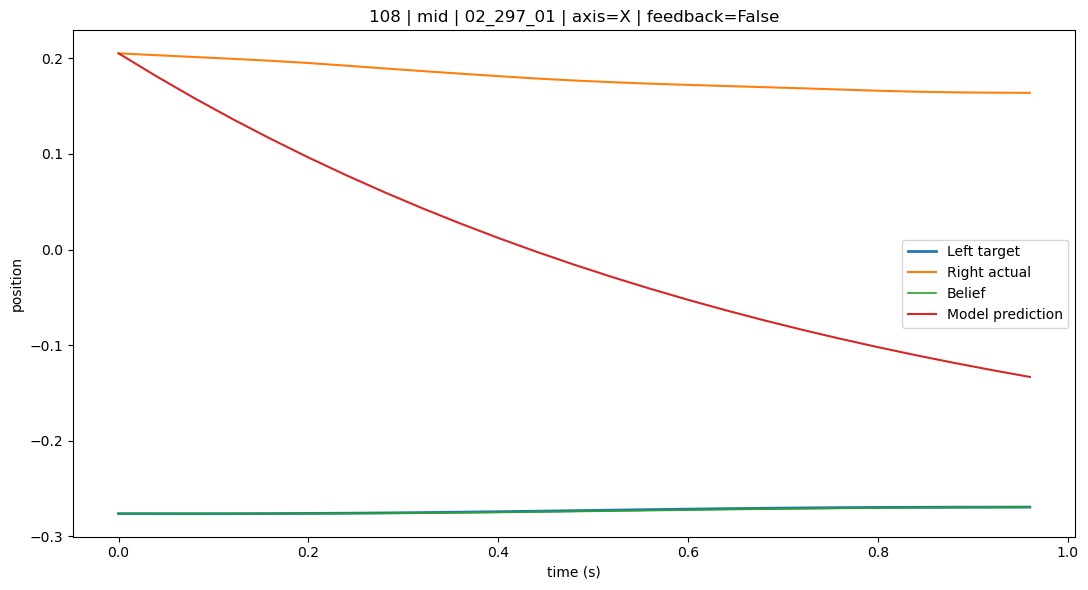

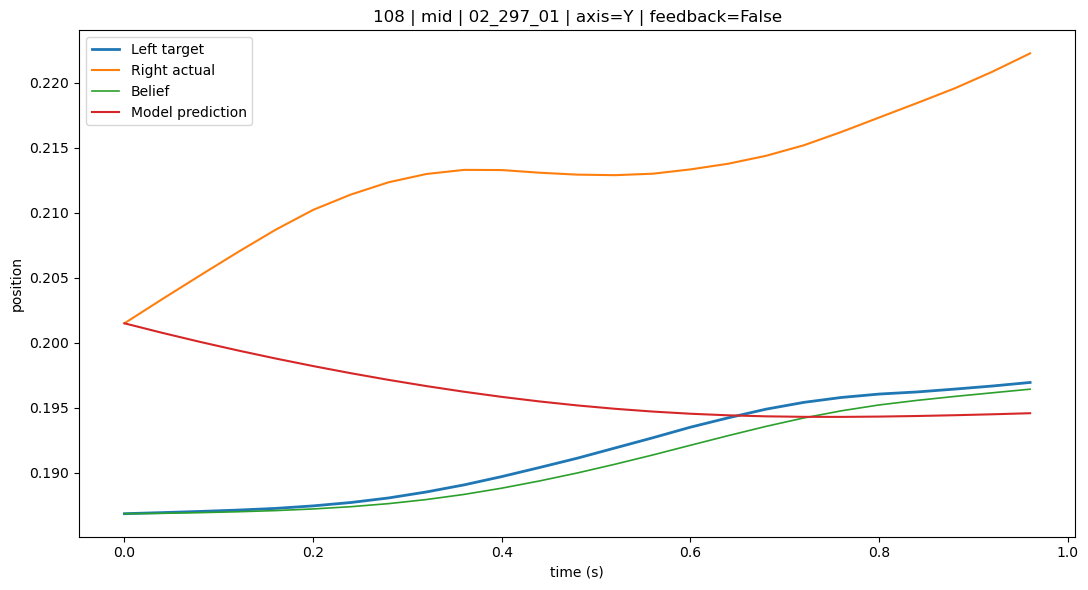

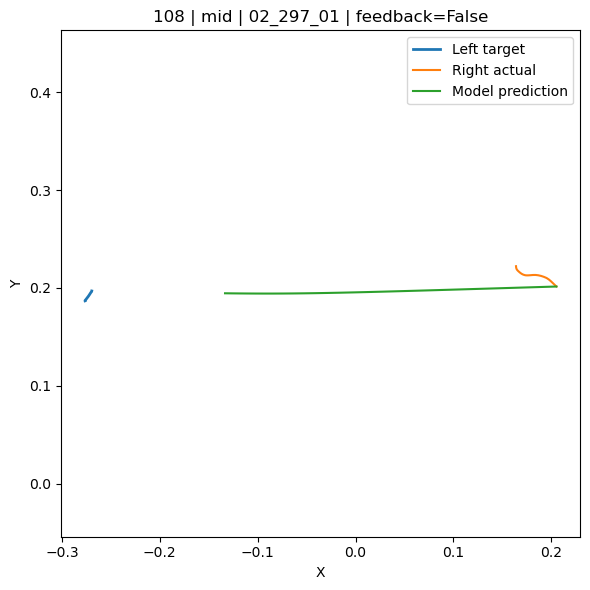

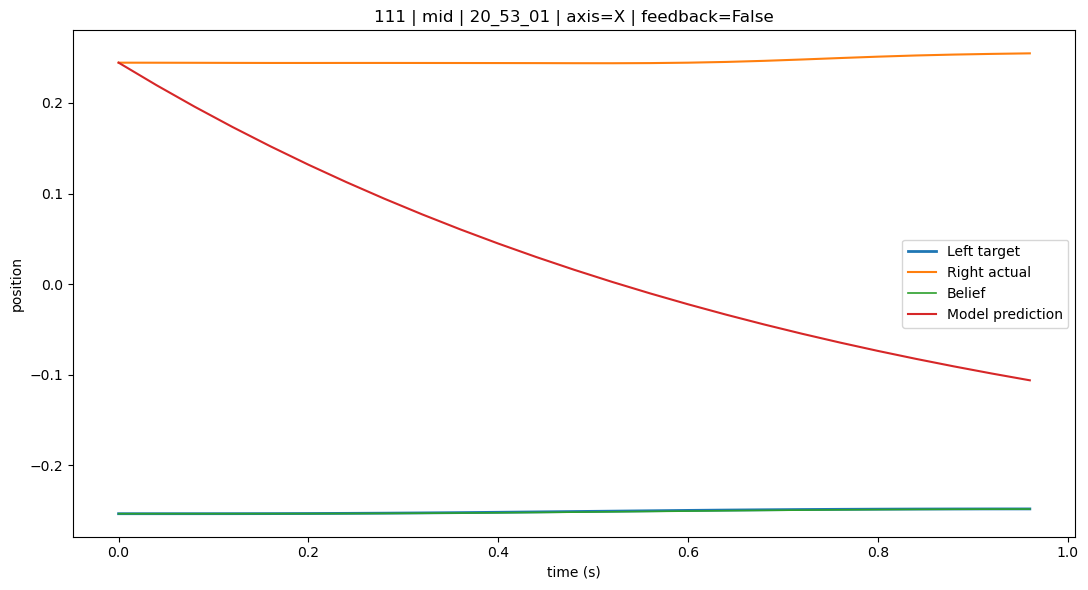

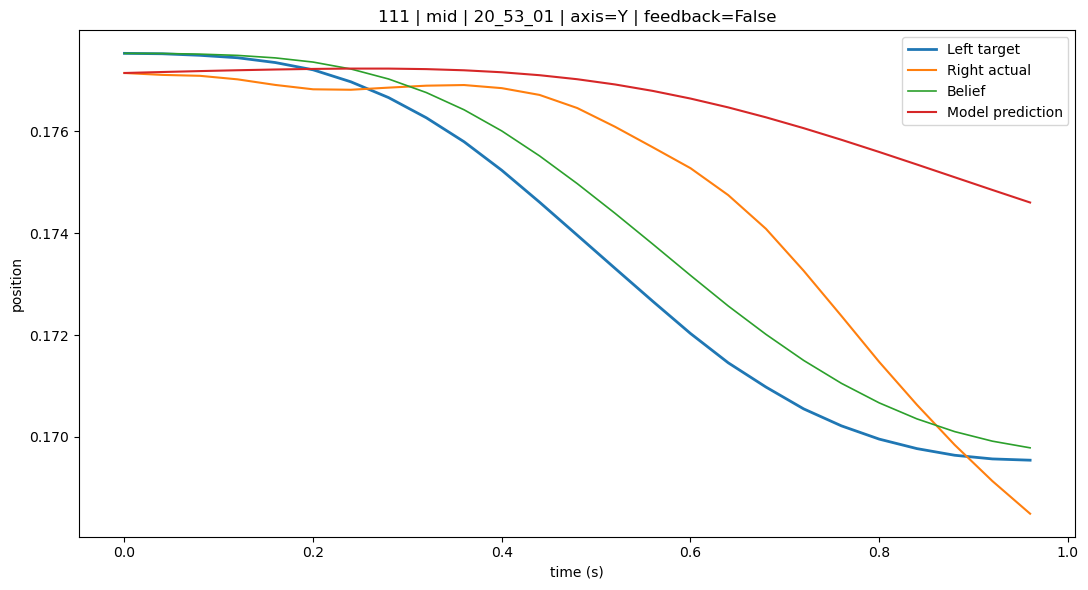

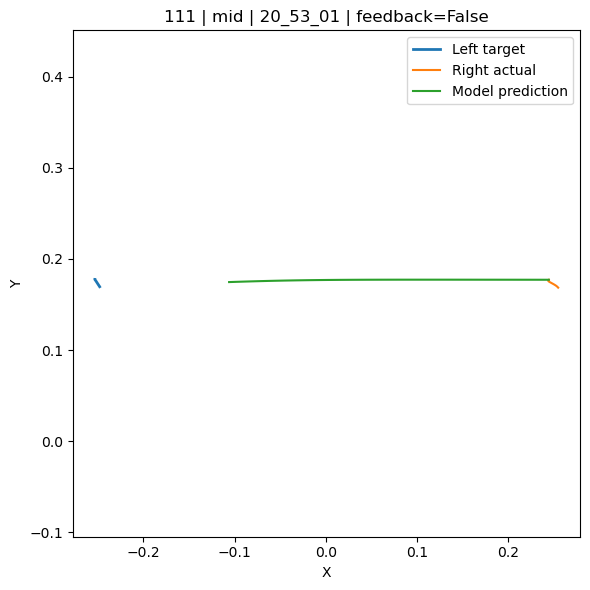

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. 基本工具
# ============================================================

def trial_sort_key(trial_name):
    nums = [int(x) for x in re.findall(r"\d+", str(trial_name))]
    if len(nums) >= 3:
        return (nums[1], nums[0], nums[2], str(trial_name))
    elif len(nums) == 2:
        return (nums[1], nums[0], 0, str(trial_name))
    elif len(nums) == 1:
        return (nums[0], 0, 0, str(trial_name))
    else:
        return (10**12, 10**12, 10**12, str(trial_name))


def as_1d_float_array(x):
    arr = np.asarray(x, dtype=float)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    else:
        arr = arr.reshape(-1)
    return arr


def interp_nan_1d(x):
    x = np.asarray(x, dtype=float).copy()
    if x.size == 0:
        return x
    finite = np.isfinite(x)
    if finite.all():
        return x
    if finite.sum() == 0:
        return np.zeros_like(x)
    idx = np.arange(x.size)
    x[~finite] = np.interp(idx[~finite], idx[finite], x[finite])
    return x


def robust_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    s1 = 1.4826 * mad
    s2 = np.std(x)
    return float(max(s1, s2, 1e-8))


def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 3 or len(b) < 3:
        return np.nan
    sa = np.std(a)
    sb = np.std(b)
    if sa < 1e-12 or sb < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def is_feedback_trial_by_rule(trial_index_1based, period=20):
    # 19,20,39,40,59,60,...
    r = trial_index_1based % period
    return (r == 19) or (r == 0)


# ============================================================
# 1. 按实验规则给 df_trials 打标签
# ============================================================

def annotate_trials_fast(
    df_trials,
    keep_first_n=300,
    instruction_n=2,
    feedback_count_includes_instruction=True,
):
    df = df_trials.copy()

    df["__trial_sort_key__"] = df["trial_name"].map(trial_sort_key)
    df = (
        df.sort_values(["subject_id", "condition", "__trial_sort_key__"], kind="stable")
          .drop(columns="__trial_sort_key__")
          .reset_index(drop=True)
    )

    df["trial_index_in_condition_all"] = (
        df.groupby(["subject_id", "condition"]).cumcount() + 1
    )

    df["kept_in_first_300"] = df["trial_index_in_condition_all"] <= keep_first_n
    df["is_instruction_trial"] = df["trial_index_in_condition_all"] <= instruction_n
    df["is_valid_trial"] = df["kept_in_first_300"] & (~df["is_instruction_trial"])

    if feedback_count_includes_instruction:
        basis = df["trial_index_in_condition_all"].values
    else:
        basis = df["trial_index_in_condition_all"].values - instruction_n

    df["feedback_trial_index_basis"] = basis
    df["is_feedback_trial"] = [
        bool(idx > 0 and keep and is_feedback_trial_by_rule(int(idx), period=20))
        for idx, keep in zip(basis, df["kept_in_first_300"].values)
    ]

    return df


# ============================================================
# 2. 从 trial 宽表提取时序
# ============================================================

def extract_trial_fast(row, position_scale=1.0, downsample=2):
    required_cols = ["Left_HandX", "Left_HandY", "Right_HandX", "Right_HandY"]
    for c in required_cols:
        if c not in row.index:
            raise KeyError(f"缺少列: {c}")

    xL = as_1d_float_array(row["Left_HandX"]) * position_scale
    yL = as_1d_float_array(row["Left_HandY"]) * position_scale
    xR = as_1d_float_array(row["Right_HandX"]) * position_scale
    yR = as_1d_float_array(row["Right_HandY"]) * position_scale

    n = min(len(xL), len(yL), len(xR), len(yR))
    if n < 8:
        raise ValueError(f"trial 太短，n={n}")

    xL = interp_nan_1d(xL[:n])
    yL = interp_nan_1d(yL[:n])
    xR = interp_nan_1d(xR[:n])
    yR = interp_nan_1d(yR[:n])

    frame_rate = float(row["frame_rate"]) if np.isfinite(row["frame_rate"]) and row["frame_rate"] > 0 else 50.0

    # 快速版：默认做时间降采样
    ds = max(int(downsample), 1)
    if ds > 1:
        xL = xL[::ds]
        yL = yL[::ds]
        xR = xR[::ds]
        yR = yR[::ds]
        frame_rate = frame_rate / ds

    dt = 1.0 / frame_rate

    return {
        "subject_id": row["subject_id"],
        "condition": row["condition"],
        "source_file": row["source_file"],
        "trial_name": row["trial_name"],
        "trial_index_in_condition_all": int(row["trial_index_in_condition_all"]),
        "is_feedback_trial": bool(row["is_feedback_trial"]),
        "frame_rate": frame_rate,
        "dt": dt,
        "t": np.arange(len(xL)) * dt,
        "xL": xL,
        "yL": yL,
        "xR": xR,
        "yR": yR,
    }


def prepare_valid_trials_fast(
    df_trials,
    keep_first_n=300,
    instruction_n=2,
    feedback_count_includes_instruction=True,
    position_scale=1.0,
    downsample=2,
    verbose=True,
):
    df_ann = annotate_trials_fast(
        df_trials=df_trials,
        keep_first_n=keep_first_n,
        instruction_n=instruction_n,
        feedback_count_includes_instruction=feedback_count_includes_instruction,
    )

    df_valid = df_ann[df_ann["is_valid_trial"]].copy().reset_index(drop=True)

    prepared = []
    dropped = []

    for _, row in df_valid.iterrows():
        try:
            prepared.append(extract_trial_fast(
                row,
                position_scale=position_scale,
                downsample=downsample
            ))
        except Exception as e:
            dropped.append({
                "subject_id": row.get("subject_id", None),
                "condition": row.get("condition", None),
                "trial_name": row.get("trial_name", None),
                "trial_index_in_condition_all": row.get("trial_index_in_condition_all", None),
                "reason": str(e),
            })

    dropped_df = pd.DataFrame(dropped)

    if verbose:
        print("总 trial 数:", len(df_ann))
        print("前300内 trial 数:", int(df_ann["kept_in_first_300"].sum()))
        print("指导语 trial 数:", int(df_ann["is_instruction_trial"].sum()))
        print("有效实验 trial 数:", int(df_ann["is_valid_trial"].sum()))
        print("成功提取 trial 数:", len(prepared))
        print("提取失败 trial 数:", len(dropped_df))
        if len(dropped_df) > 0:
            print(dropped_df["reason"].value_counts())

    return df_ann, prepared, dropped_df


# ============================================================
# 3. 快速代理模型：belief + first-order controller
# ============================================================

def simulate_axis_fast(xL, xR, delay, lambda_nf, lambda_fb, beta, has_feedback):
    """
    快速代理版单轴模型

    belief:
        xhat[k] = xhat[k-1] + lambda * (xL[k-delay] - xhat[k-1])

    controller:
        xpred[k] = xpred[k-1] + beta * (xhat[k-1] - xpred[k-1])

    其中 lambda 在 feedback / no-feedback trial 上可不同。
    """
    n = len(xL)
    xhat = np.zeros(n, dtype=float)
    xpred = np.zeros(n, dtype=float)
    innov = np.zeros(n, dtype=float)

    xhat[0] = xL[0]
    xpred[0] = xR[0]

    lam = float(lambda_fb if has_feedback else lambda_nf)

    for k in range(1, n):
        kd = max(0, k - int(delay))
        obs = xL[kd]
        innov[k] = obs - xhat[k - 1]
        xhat[k] = xhat[k - 1] + lam * innov[k]
        xpred[k] = xpred[k - 1] + beta * (xhat[k - 1] - xpred[k - 1])

    rmse = float(np.sqrt(np.mean((xR - xpred) ** 2)))
    corr = corr_safe(xR, xpred)

    return {
        "xhat": xhat,
        "xpred": xpred,
        "innov": innov,
        "rmse": rmse,
        "corr": corr,
    }


def simulate_trial_fast(trial, params):
    out_x = simulate_axis_fast(
        trial["xL"], trial["xR"],
        delay=params["delay"],
        lambda_nf=params["lambda_nf"],
        lambda_fb=params["lambda_fb"],
        beta=params["beta"],
        has_feedback=trial["is_feedback_trial"],
    )

    out_y = simulate_axis_fast(
        trial["yL"], trial["yR"],
        delay=params["delay"],
        lambda_nf=params["lambda_nf"],
        lambda_fb=params["lambda_fb"],
        beta=params["beta"],
        has_feedback=trial["is_feedback_trial"],
    )

    rmse_2d = float(np.sqrt(np.mean(
        (trial["xR"] - out_x["xpred"]) ** 2 +
        (trial["yR"] - out_y["xpred"]) ** 2
    )))

    # 用归一化误差做目标函数，减少不同 trial 振幅的影响
    sx = max(robust_std(trial["xR"]), 1e-3)
    sy = max(robust_std(trial["yR"]), 1e-3)

    loss = (
        np.mean(((trial["xR"] - out_x["xpred"]) / sx) ** 2) +
        np.mean(((trial["yR"] - out_y["xpred"]) / sy) ** 2)
    )

    return {
        "subject_id": trial["subject_id"],
        "condition": trial["condition"],
        "source_file": trial["source_file"],
        "trial_name": trial["trial_name"],
        "trial_index_in_condition_all": trial["trial_index_in_condition_all"],
        "is_feedback_trial": trial["is_feedback_trial"],
        "t": trial["t"],
        "xL": trial["xL"], "yL": trial["yL"],
        "xR": trial["xR"], "yR": trial["yR"],
        "xhat_x": out_x["xhat"], "xhat_y": out_y["xhat"],
        "xpred": out_x["xpred"], "ypred": out_y["xpred"],
        "innov_x": out_x["innov"], "innov_y": out_y["innov"],
        "rmse_x": out_x["rmse"], "rmse_y": out_y["rmse"],
        "corr_x": out_x["corr"], "corr_y": out_y["corr"],
        "rmse_2d": rmse_2d,
        "loss": float(loss),
    }


# ============================================================
# 4. 条件拟合：小网格搜索
# ============================================================

def select_fit_subset(trials, fit_trial_cap=60):
    if fit_trial_cap is None or len(trials) <= fit_trial_cap:
        return trials

    idx = np.linspace(0, len(trials) - 1, fit_trial_cap).round().astype(int)
    idx = np.unique(idx)
    return [trials[i] for i in idx]


def fit_condition_fast(
    trials,
    condition_name=None,
    fit_trial_cap=60,
    delay_grid=(0, 1, 2, 3, 4, 5, 6),
    lambda_nf_grid=(0.05, 0.10, 0.20, 0.35),
    lambda_fb_grid=(0.20, 0.40, 0.70, 1.00),
    beta_grid=(0.05, 0.10, 0.20, 0.35, 0.50),
    verbose=True,
):
    """
    很小的离散网格搜索。
    默认只用一部分 trial 找参数，找到后再在全体 trial 上回代。
    """
    if len(trials) == 0:
        raise ValueError("该 condition 没有可用 trial。")

    fit_trials = select_fit_subset(trials, fit_trial_cap=fit_trial_cap)

    if verbose:
        print(f"\n开始快速拟合 condition = {condition_name}")
        print(f"  全部 trial 数: {len(trials)}")
        print(f"  用于找参数的 trial 数: {len(fit_trials)}")

    best_loss = np.inf
    best_params = None
    grid_rows = []

    total_grid = len(delay_grid) * len(lambda_nf_grid) * len(lambda_fb_grid) * len(beta_grid)
    done = 0

    for delay in delay_grid:
        for lambda_nf in lambda_nf_grid:
            for lambda_fb in lambda_fb_grid:
                for beta in beta_grid:
                    done += 1
                    losses = []

                    params = {
                        "delay": int(delay),
                        "lambda_nf": float(lambda_nf),
                        "lambda_fb": float(lambda_fb),
                        "beta": float(beta),
                    }

                    for tr in fit_trials:
                        out = simulate_trial_fast(tr, params)
                        losses.append(out["loss"])

                    mean_loss = float(np.mean(losses))

                    grid_rows.append({
                        "condition": condition_name,
                        "delay": delay,
                        "lambda_nf": lambda_nf,
                        "lambda_fb": lambda_fb,
                        "beta": beta,
                        "loss": mean_loss,
                    })

                    if mean_loss < best_loss:
                        best_loss = mean_loss
                        best_params = params.copy()

                    if verbose and done % 100 == 0:
                        print(f"  已完成 {done}/{total_grid} 组参数")

    # 用最优参数回代所有 trial
    trial_outputs = []
    trial_rows = []

    innov_nf = []
    innov_fb = []

    for tr in trials:
        out = simulate_trial_fast(tr, best_params)
        trial_outputs.append(out)

        # sigma proxy：用 innovation 的标准差做快速近似
        if tr["is_feedback_trial"]:
            innov_fb.append(out["innov_x"][1:])
            innov_fb.append(out["innov_y"][1:])
        else:
            innov_nf.append(out["innov_x"][1:])
            innov_nf.append(out["innov_y"][1:])

        trial_rows.append({
            "subject_id": out["subject_id"],
            "condition": out["condition"],
            "source_file": out["source_file"],
            "trial_name": out["trial_name"],
            "trial_index_in_condition_all": out["trial_index_in_condition_all"],
            "is_feedback_trial": out["is_feedback_trial"],
            "rmse_x": out["rmse_x"],
            "rmse_y": out["rmse_y"],
            "rmse_2d": out["rmse_2d"],
            "corr_x": out["corr_x"],
            "corr_y": out["corr_y"],
            "loss": out["loss"],
        })

    trial_metrics_df = pd.DataFrame(trial_rows)
    grid_df = pd.DataFrame(grid_rows).sort_values("loss").reset_index(drop=True)

    sigma_p_proxy = float(np.std(np.concatenate(innov_nf))) if len(innov_nf) > 0 else np.nan
    sigma_v_proxy = float(np.std(np.concatenate(innov_fb))) if len(innov_fb) > 0 else np.nan

    summary = {
        "condition": condition_name,
        "n_trials": len(trials),
        "n_fit_trials": len(fit_trials),
        "n_feedback_trials": int(sum(tr["is_feedback_trial"] for tr in trials)),
        "n_no_feedback_trials": int(sum((not tr["is_feedback_trial"]) for tr in trials)),
        "delay": best_params["delay"],
        "lambda_nf": best_params["lambda_nf"],
        "lambda_fb": best_params["lambda_fb"],
        "beta": best_params["beta"],
        "sigma_p_proxy": sigma_p_proxy,
        "sigma_v_proxy": sigma_v_proxy,
        "mean_rmse_2d": float(trial_metrics_df["rmse_2d"].mean()),
        "mean_corr_x": float(trial_metrics_df["corr_x"].mean()),
        "mean_corr_y": float(trial_metrics_df["corr_y"].mean()),
        "fit_loss": best_loss,
    }

    return {
        "condition": condition_name,
        "best_params": best_params,
        "summary": summary,
        "grid_df": grid_df,
        "trial_outputs": trial_outputs,
        "trial_metrics_df": trial_metrics_df,
    }


# ============================================================
# 5. 跑所有 condition
# ============================================================

def fit_all_conditions_fast(
    df_trials,
    keep_first_n=300,
    instruction_n=2,
    feedback_count_includes_instruction=True,
    position_scale=1.0,
    downsample=2,
    fit_trial_cap=60,
    delay_grid=(0, 1, 2, 3, 4, 5, 6),
    lambda_nf_grid=(0.05, 0.10, 0.20, 0.35),
    lambda_fb_grid=(0.20, 0.40, 0.70, 1.00),
    beta_grid=(0.05, 0.10, 0.20, 0.35, 0.50),
    verbose=True,
):
    df_ann, prepared_trials, dropped_df = prepare_valid_trials_fast(
        df_trials=df_trials,
        keep_first_n=keep_first_n,
        instruction_n=instruction_n,
        feedback_count_includes_instruction=feedback_count_includes_instruction,
        position_scale=position_scale,
        downsample=downsample,
        verbose=verbose,
    )

    grouped = {}
    for tr in prepared_trials:
        grouped.setdefault(tr["condition"], []).append(tr)

    fit_results = {}
    summary_rows = []
    trial_rows = []

    for condition_name, trials in grouped.items():
        res = fit_condition_fast(
            trials=trials,
            condition_name=condition_name,
            fit_trial_cap=fit_trial_cap,
            delay_grid=delay_grid,
            lambda_nf_grid=lambda_nf_grid,
            lambda_fb_grid=lambda_fb_grid,
            beta_grid=beta_grid,
            verbose=verbose,
        )
        fit_results[condition_name] = res
        summary_rows.append(res["summary"])

        tmp = res["trial_metrics_df"].copy()
        tmp["fit_group"] = condition_name
        trial_rows.append(tmp)

    summary_df = pd.DataFrame(summary_rows).sort_values("condition").reset_index(drop=True)
    trial_metrics_df = pd.concat(trial_rows, axis=0, ignore_index=True) if len(trial_rows) > 0 else pd.DataFrame()

    return {
        "df_annotated": df_ann,
        "prepared_trials": prepared_trials,
        "dropped_df": dropped_df,
        "fit_results": fit_results,
        "summary_df": summary_df,
        "trial_metrics_df": trial_metrics_df,
    }


# ============================================================
# 6. 结果查看与作图
# ============================================================

def extract_sigma_table_fast(all_fit):
    df = all_fit["summary_df"].copy()
    keep = [
        "condition",
        "n_trials",
        "n_fit_trials",
        "n_feedback_trials",
        "n_no_feedback_trials",
        "delay",
        "lambda_nf",
        "lambda_fb",
        "beta",
        "sigma_p_proxy",
        "sigma_v_proxy",
        "mean_rmse_2d",
        "mean_corr_x",
        "mean_corr_y",
        "fit_loss",
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()


def show_trial_rule_check_fast(df_annotated, subject_id=None, condition=None, n=60):
    df = df_annotated.copy()
    if subject_id is not None:
        df = df[df["subject_id"] == subject_id]
    if condition is not None:
        df = df[df["condition"] == condition]

    cols = [
        "subject_id", "condition", "trial_name",
        "trial_index_in_condition_all",
        "kept_in_first_300",
        "is_instruction_trial",
        "is_valid_trial",
        "is_feedback_trial",
    ]
    return df[cols].head(n).reset_index(drop=True)


def plot_trial_fit_fast(trial_output, axis="x", figsize=(11, 6)):
    if axis not in ["x", "y"]:
        raise ValueError("axis 只能是 'x' 或 'y'")

    t = trial_output["t"]
    is_fb = trial_output["is_feedback_trial"]

    if axis == "x":
        target = trial_output["xL"]
        actual = trial_output["xR"]
        belief = trial_output["xhat_x"]
        pred = trial_output["xpred"]
        axis_name = "X"
    else:
        target = trial_output["yL"]
        actual = trial_output["yR"]
        belief = trial_output["xhat_y"]
        pred = trial_output["ypred"]
        axis_name = "Y"

    plt.figure(figsize=figsize)
    if is_fb:
        plt.gca().set_facecolor("#f3f3f3")

    plt.plot(t, target, label="Left target", linewidth=2)
    plt.plot(t, actual, label="Right actual", linewidth=1.5)
    plt.plot(t, belief, label="Belief", linewidth=1.2)
    plt.plot(t, pred, label="Model prediction", linewidth=1.5)
    plt.xlabel("time (s)")
    plt.ylabel("position")
    plt.title(
        f"{trial_output['subject_id']} | {trial_output['condition']} | "
        f"{trial_output['trial_name']} | axis={axis_name} | feedback={is_fb}"
    )
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_trial_2d_fast(trial_output, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.plot(trial_output["xL"], trial_output["yL"], label="Left target", linewidth=2)
    plt.plot(trial_output["xR"], trial_output["yR"], label="Right actual", linewidth=1.5)
    plt.plot(trial_output["xpred"], trial_output["ypred"], label="Model prediction", linewidth=1.5)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(
        f"{trial_output['subject_id']} | {trial_output['condition']} | "
        f"{trial_output['trial_name']} | feedback={trial_output['is_feedback_trial']}"
    )
    plt.axis("equal")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_condition_examples_fast(fit_result, n_examples=2, sort_by="rmse_2d"):
    df = fit_result["trial_metrics_df"].copy()
    if len(df) == 0:
        print("没有可画的 trial")
        return

    df = df.sort_values(sort_by).reset_index(drop=True)

    if len(df) <= n_examples:
        chosen = df["trial_name"].tolist()
    else:
        idxs = np.linspace(0, len(df) - 1, n_examples).round().astype(int)
        chosen = df.loc[idxs, "trial_name"].tolist()

    out_map = {x["trial_name"]: x for x in fit_result["trial_outputs"]}

    for name in chosen:
        out = out_map[name]
        plot_trial_fit_fast(out, axis="x")
        plot_trial_fit_fast(out, axis="y")
        plot_trial_2d_fast(out)


# ============================================================
# 7. 最小调用示例
# ============================================================

# 先检查 trial 规则是否正确
df_ann, prepared_trials, dropped_df = prepare_valid_trials_fast(
    df_trials,
    keep_first_n=300,
    instruction_n=2,
   feedback_count_includes_instruction=True,   # 如果 feedback 编号包含前2个指导语，就保持 True
    position_scale=1.0,                         # 如果原始单位是 m，想转 cm 就改成 100.0
    downsample=2,                               # 先降到 25Hz 跑快速版
    verbose=True,
)
display(show_trial_rule_check_fast(df_ann, n=60))
display(dropped_df.head())

#正式快速拟合
all_fit_fast = fit_all_conditions_fast(
    df_trials=df_trials,
    keep_first_n=300,
    instruction_n=2,
    feedback_count_includes_instruction=True,
    position_scale=1.0,
    downsample=2,          # 先用 2；如果还想更快，可以设 4
    fit_trial_cap=60,      # 先用每个 condition 的 60 个 trial 找参数
    delay_grid=(0, 1, 2, 3, 4, 5, 6),
    lambda_nf_grid=(0.05, 0.10, 0.20, 0.35),
    lambda_fb_grid=(0.20, 0.40, 0.70, 1.00),
    beta_grid=(0.05, 0.10, 0.20, 0.35, 0.50),
    verbose=True,
)
#
sigma_table_fast = extract_sigma_table_fast(all_fit_fast)
display(sigma_table_fast)
display(all_fit_fast["trial_metrics_df"].head())

# 看某个 condition
mid_fit_fast = all_fit_fast["fit_results"]["mid"]
display(pd.DataFrame([mid_fit_fast["summary"]]).T)
display(mid_fit_fast["grid_df"].head(10))

# 画几个 trial 看真实轨迹和模型预测是否基本一致
plot_condition_examples_fast(mid_fit_fast, n_examples=2)